# Graphicalizing Aesop's Fables

This notebook downloads the public-domain Project Gutenberg text for [Æsop's Fables #53103](https://www.gutenberg.org/ebooks/53103), splits it into tale-sized documents, and sends those documents through the ontology-guided semantic pipeline.

The notebook uses the package's default OpenAI `gpt-4.1-mini` client. Set `OPENAI_API_KEY` in the environment before running the model cell. The key is read by the OpenAI SDK and is never stored in this notebook.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from semantic_graphicalizer import SemanticGraphicalizer, load_aesop_fables

ROOT = Path.cwd()
if not (ROOT / 'configs').exists():
    ROOT = ROOT.parent

stories = load_aesop_fables(limit=1, cache_dir=ROOT / 'data' / 'raw')
[(story.splitlines()[0], len(story)) for story in stories]

[('THE DAW IN BORROWED FEATHERS', 859)]

In [2]:
len(stories), [story.splitlines()[0] for story in stories]

(1, ['THE DAW IN BORROWED FEATHERS'])

## OpenAI model

The transformer creates the default `OpenAIModelClient` when `model` is omitted. It uses `gpt-4.1-mini` through the Responses API and reads `OPENAI_API_KEY` from the environment.

In [3]:
graphicalizer = SemanticGraphicalizer(
    ontology=ROOT / 'configs' / 'ontologies' / 'aesop.yaml',
    prompts=ROOT / 'configs' / 'prompts' / 'aesop.yaml',
)
traces = graphicalizer.fit([stories[0]]).transform_with_trace([stories[0]])
trace = traces[0]
[(p.text, p.proposition_id) for p in trace.propositions]

[SemanticGraphicalizer] ready: model=OpenAIModelClient, ontology=aesop-narrative, domain=aesop-narrative
[document-0] processing document: chars=859
[document-0] segment: 1 -> 1 | 0.1 ms | input_chars=859, chunk_chars=859
[document-0 chunk-0] compiling semantic stages
[document-0 chunk-0] summarize: 1 -> 1 | 5.0 s | input_chars=859, output_chars=531
[document-0 chunk-0] normalize: 1 -> 1 | 3.4 s | input_chars=531, output_chars=652
[document-0 chunk-0] decompose: 1 -> 10 | 9.1 s
[document-0 chunk-0] triple: 10 -> 10 | 12.5 s
[document-0] integrate: 10 -> 10 | 0.4 ms | nodes=15, edges=10
[document-0] total: 1 -> 1 | 30.1 s | chunks=1, propositions=10, triples=10, nodes=15, edges=10


[('A jackdaw is an animal characterized by vanity', 'document-0:chunk-0:p1'),
 ('The jackdaw desires to be as beautiful as peacocks',
  'document-0:chunk-0:p2'),
 ('The jackdaw performs the action of adorning itself with borrowed peacock feathers',
  'document-0:chunk-0:p3'),
 ('The jackdaw wants to mingle with the peacocks', 'document-0:chunk-0:p4'),
 ('The peacocks are a distinct group of animals', 'document-0:chunk-0:p5'),
 ("The jackdaw's affected behavior causes the peacocks to attack it and remove the borrowed feathers",
  'document-0:chunk-0:p6'),
 ('The peacocks removing the borrowed feathers restores the jackdaw to its original appearance',
  'document-0:chunk-0:p7'),
 ('Upon returning to its fellow jackdaws, the jackdaw encounters rejection and contempt from them',
  'document-0:chunk-0:p8'),
 ('The fellow jackdaws reject and feel contempt towards the jackdaw due to its previous arrogance',
  'document-0:chunk-0:p9'),
 ('The narrative teaches the moral that vanity and pretend

In [4]:
graphicalizer.display(trace.graph, mode="text")

Animal
	jackdaw
		has_trait - Trait
		wants - Goal
		performs - Action
		wants - Goal
		interacts_with - Animal
Trait
	vanity
Goal
	to be as beautiful as peacocks
Action
	adorning itself with borrowed peacock feathers
Goal
	to mingle with the peacocks
Animal
	peacocks
		has_trait - Trait
Trait
	distinct group
Action
	jackdaw's affected behavior
		causes - Action
Action
	peacocks attack it and remove the borrowed feathers
Action
	peacocks removing the borrowed feathers
		causes - Goal
Goal
	jackdaw restoring to original appearance
Animal
	fellow jackdaws
		has_trait - Trait
Trait
	rejection and contempt due to previous arrogance
Character
	narrative
		teaches - Moral
Moral
	vanity and pretending to be something one is not result in humiliation and loss of acceptance

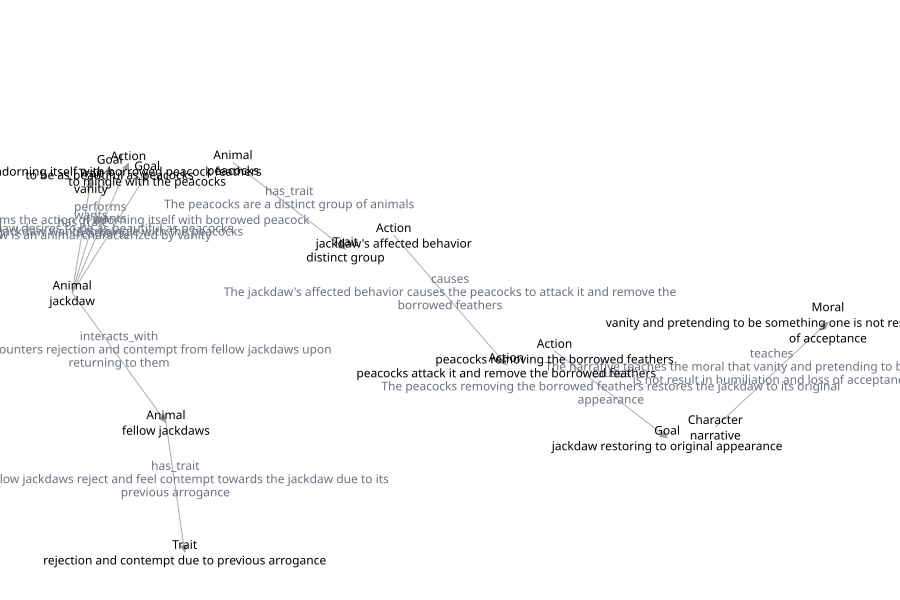

In [5]:
# Deterministic alternative: NetworkX Kamada-Kawai layout.
graphicalizer.display(trace.graph, mode="static")

In [6]:
graphicalizer.display(trace.graph, mode="dynamic", charge_strength=-1)